In [1]:
import pickle as pkl
import sys
from collections import Counter
import os
import pandas as pd
import numpy as np

# 重新统计，避免重复运行时累加
top_pathways = []
seeds=np.arange(42,52)
sys.path.append('./model/')  # 添加model文件夹到路径

for seed in seeds:
    print(f'Processing seed: {seed}')
    model_path = f'results/real_exp/beta_T2D_processed/scKnockPath_results/scKnockPath_l1_ratio_0.02_normal_type 2 diabetes mellitus_disease_type B pancreatic cell_knockoff_seed={seed}.pkl'
    with open(model_path, 'rb') as f:
        model = pkl.load(f)

    selected_pathways = model.rank_pathways()[::-1].head(len(model.select_pathway(0.2)))['pathway_names'][:10].tolist()
    top_pathways.extend(selected_pathways)

# 统计频率并转为 DataFrame
pathway_freq = Counter(top_pathways)
freq_df = (
    pd.DataFrame(pathway_freq.items(), columns=['Pathway', 'Frequency'])
    .sort_values(['Frequency', 'Pathway'], ascending=[False, True])
    .reset_index(drop=True)
)
freq_df['Proportion'] = freq_df['Frequency'] / len(seeds)

# 保存为 csv
out_dir = './results/real_exp'
os.makedirs(out_dir, exist_ok=True)
out_csv = f'{out_dir}/T2D_pathway_frequency_across_seeds.csv'
freq_df.to_csv(out_csv, index=False)

print(f'Saved: {out_csv}')
freq_df

Processing seed: 42
Processing seed: 43
Processing seed: 44
Processing seed: 45
Processing seed: 46
Processing seed: 47
Processing seed: 48
Processing seed: 49
Processing seed: 50
Processing seed: 51
Saved: ./results/real_exp/T2D_pathway_frequency_across_seeds.csv


,Pathway,Frequency,Proportion
0,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,9,0.9
1,REACTOME_PEPTIDE_HORMONE_METABOLISM,9,0.9
2,REACTOME_SARS_COV_INFECTIONS,8,0.8
3,REACTOME_INTERFERON_SIGNALING,7,0.7
4,REACTOME_NGF_STIMULATED_TRANSCRIPTION,7,0.7
5,REACTOME_REGULATION_OF_INSULIN_LIKE_GROWTH_FAC...,7,0.7
6,REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES...,6,0.6
7,REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION,4,0.4
8,REACTOME_L1CAM_INTERACTIONS,3,0.3
9,REACTOME_METABOLISM_OF_CARBOHYDRATES,3,0.3


In [5]:

import sys
import pickle
import pandas as pd
import scanpy as sc
# 将点大小设为该通路在adata中存在的基因数（归一化到可视范围）
import numpy as np
import matplotlib.pyplot as plt
import os
sys.path.append('./model/')  # 添加model文件夹到路径

plt.rcParams['pdf.fonttype'] = 42

def load_results(n_top=5,seed=42):
    with open(f'results/real_exp/beta_T2D_processed/scKnockPath_results/scKnockPath_l1_ratio_0.02_normal_type 2 diabetes mellitus_disease_type B pancreatic cell_knockoff_seed={seed}.pkl', 'rb') as f:
        model = pickle.load(f)

    
    print(f'scKnockPath selects {len(model.select_pathway(0.2))} pathways under FDR 0.2')
    
    # 定义结果文件路径
    results_base = 'results/real_exp/beta_T2D_processed'
    methods_results = {}
    
    # PADOG结果
    padog_file = os.path.join(results_base, f'PADOG_results/PADOG_type 2 diabetes mellitus_vs_normal_type B pancreatic cell_disease.csv')
    if os.path.exists(padog_file):
        padog_results = pd.read_csv(padog_file)
        methods_results['PADOG'] = padog_results
        print(f"✅ PADOG结果加载成功: {padog_results.shape[0]} 通路")
    else:
        print(f"❌ PADOG结果文件未找到: {padog_file}")

    # GSEA结果
    # gsea_file = os.path.join(results_base, f'GSEA_results/GSEA_{cell_type}_AAB+_vs_ND.csv')
    # gsea_file = os.path.join(results_base, f'GSEA_results/GSEA_AAB+_vs_ND_{cell_type}_diabetes_status.csv')
    gsea_file = os.path.join(results_base, f'GSEA_results/GSEA_type 2 diabetes mellitus_vs_normal_type B pancreatic cell_disease.csv')
    if os.path.exists(gsea_file):
        gsea_results = pd.read_csv(gsea_file)
        methods_results['GSEA'] = gsea_results
        print(f"✅ GSEA结果加载成功: {gsea_results.shape[0]} 通路")
    else:
        print(f"❌ GSEA结果文件未找到: {gsea_file}")

    # CAMERA结果
    camera_file = os.path.join(results_base, f'CAMERA_results/CAMERA_type 2 diabetes mellitus_vs_normal_type B pancreatic cell_disease.csv')
    if os.path.exists(camera_file):
        camera_results = pd.read_csv(camera_file)
        methods_results['CAMERA'] = camera_results
        print(f"✅ CAMERA结果加载成功: {camera_results.shape[0]} 通路")
    else:
        print(f"❌ CAMERA结果文件未找到: {camera_file}")

    # SCPA结果
    scpa_file = os.path.join(results_base, f'SCPA_results/SCPA_type 2 diabetes mellitus_vs_normal_type B pancreatic cell_disease.csv')
    if os.path.exists(scpa_file):
        scpa_results = pd.read_csv(scpa_file)
        methods_results['SCPA'] = scpa_results
        print(f"✅ SCPA结果加载成功: {scpa_results.shape[0]} 通路")
    else:
        print(f"❌ SCPA结果文件未找到: {scpa_file}")
        
    # SOGL结果
    sogl_file = 'results/real_exp/beta_T2D_processed/SOGL_results/SOGL_l1=0.02_normal_type 2 diabetes mellitus_disease_type B pancreatic cell.pkl'
    if os.path.exists(sogl_file):
        with open(sogl_file, 'rb') as f:
            sogl_model = pickle.load(f)
        sogl_pathways=model.pathway_names[sogl_model.chosen_groups_]
        print(f"✅ SOGL结果加载成功: {len(sogl_pathways)} 通路")
    else:
        print(f"❌ SOGL结果文件未找到: {sogl_file}")
    
    methods_results['SOGL'] = pd.DataFrame({'Pathway': sogl_pathways})
    
    # OGL结果
    ogl_file = 'results/real_exp/beta_T2D_processed/SOGL_results/SOGL_l1=0.0_normal_type 2 diabetes mellitus_disease_type B pancreatic cell.pkl'
    if os.path.exists(ogl_file):
        with open(ogl_file, 'rb') as f:
            ogl_model = pickle.load(f)
        ogl_pathways=model.pathway_names[ogl_model.chosen_groups_]
        print(f"✅ OGL结果加载成功: {len(ogl_pathways)} 通路")
    else:
        print(f"❌ OGL结果文件未找到: {ogl_file}")
    methods_results['OGL'] = pd.DataFrame({'Pathway': ogl_pathways})

    # scKP结果
    methods_results['scKnockPath'] = pd.DataFrame(model.rank_pathways()[::-1][:len(model.select_pathway(0.2))]['pathway_names']).rename(columns={'pathway_names':'Pathway'})
    print(f"\n总共加载了 {len(methods_results)} 种方法的结果")


    return model, methods_results

model, methods_results = load_results(seed=52)
# model, methods_results

scKnockPath selects 10 pathways under FDR 0.2
✅ PADOG结果加载成功: 16 通路
✅ GSEA结果加载成功: 61 通路
✅ CAMERA结果加载成功: 0 通路
✅ SCPA结果加载成功: 67 通路
✅ SOGL结果加载成功: 17 通路
✅ OGL结果加载成功: 8 通路

总共加载了 7 种方法的结果


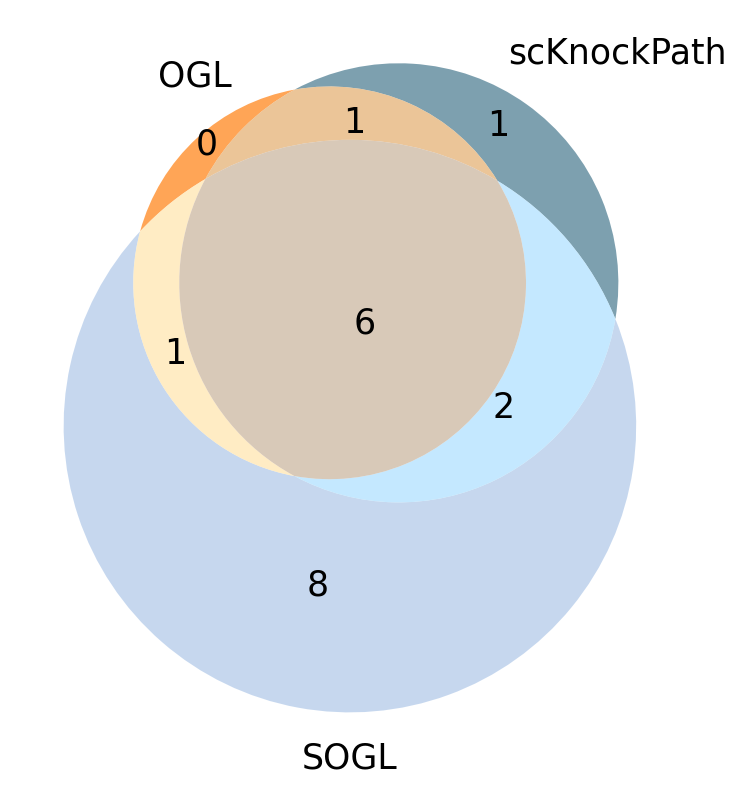

In [2]:
from matplotlib_venn import venn3

# 提取三个方法对应的通路集合
ogl_set = set(methods_results['OGL']['Pathway'].dropna().astype(str))
sckp_set = set(methods_results['scKnockPath']['Pathway'].dropna().astype(str))
sogl_set = set(methods_results['SOGL']['Pathway'].dropna().astype(str))

# 绘制 venn3
plt.figure(figsize=(8, 8))
v = venn3(
    [ogl_set, sckp_set, sogl_set],
    set_labels=('OGL', 'scKnockPath', 'SOGL'),
    set_colors=('#FF7F0E', '#46788E', '#AEC7E8'),
    alpha=0.7
)


# 可选：调整字体大小
for text in v.set_labels:
    if text:
        text.set_fontsize(25)
for text in v.subset_labels:
    if text:
        text.set_fontsize(25)

plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/venn_diagram_OGL_scKnockPath_SOGL.pdf')
plt.show()


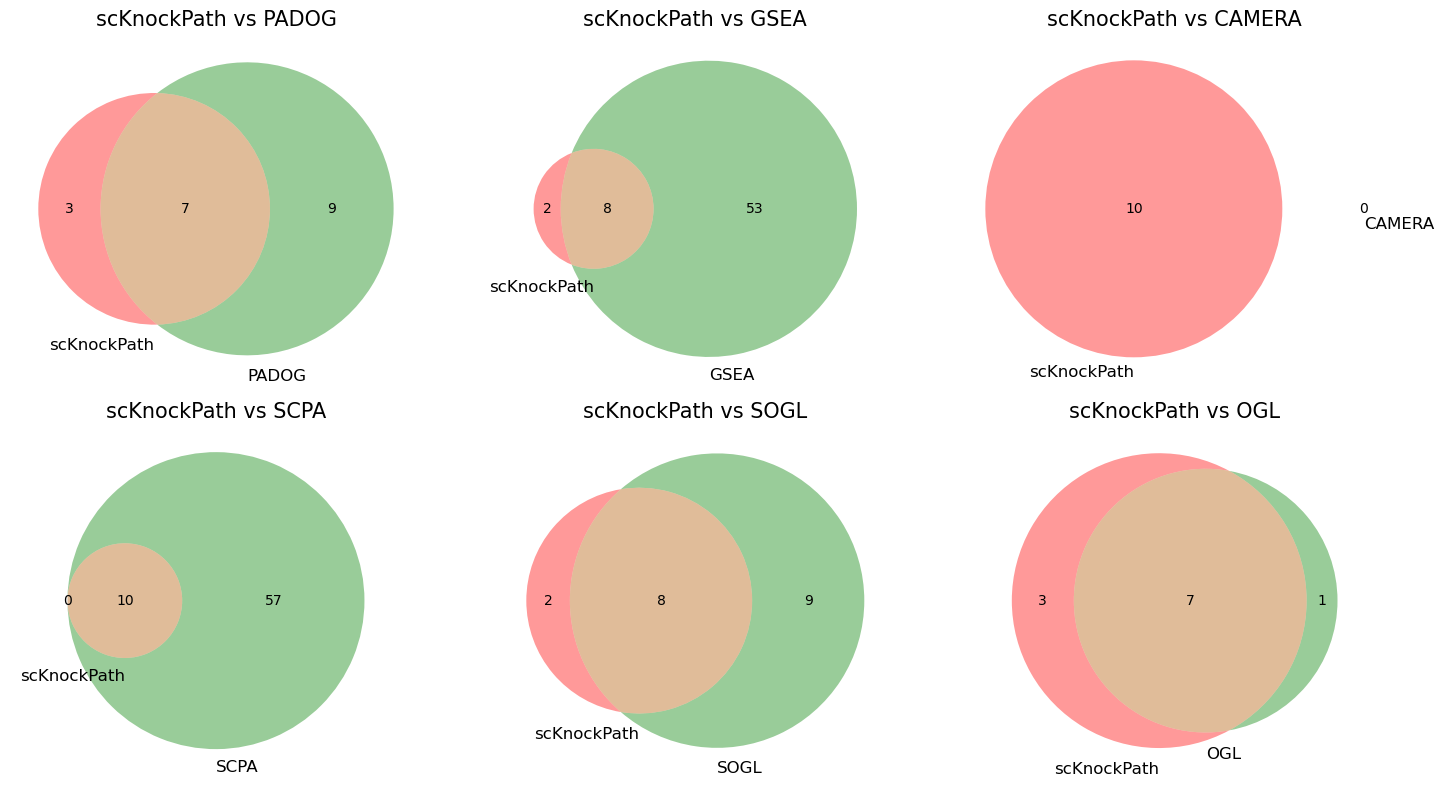

In [6]:
from matplotlib_venn import venn2
import math

# 设置 method_results中 GSEA 的 df 的 Term 列为 Pathway 列，方便后续处理
if 'GSEA' in methods_results:
    methods_results['GSEA'] = methods_results['GSEA'].rename(columns={'Term': 'Pathway'})   
# 将每个方法的通路转为集合
method_sets = {
    m: set(df['Pathway'].dropna().astype(str))
    for m, df in methods_results.items()
    if 'Pathway' in df.columns
}

# 以 scKnockPath 为参照，和其它每个方法分别画 venn2
ref_method = 'scKnockPath'
other_methods = [m for m in method_sets.keys() if m != ref_method]

n = len(other_methods)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, m in enumerate(other_methods):
    ax = axes[i]
    venn2(
        [method_sets[ref_method], method_sets[m]],
        set_labels=(ref_method, m),
        ax=ax,
    )
    inter_n = len(method_sets[ref_method] & method_sets[m])
    ax.set_title(f'{ref_method} vs {m}',size=15)

# 隐藏多余子图
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
cell_type = 'type B pancreatic cell'
plt.savefig(f'./results/real_exp/beta_T2D_processed/venn_T2D_{cell_type}_all_methods.pdf')
plt.show()


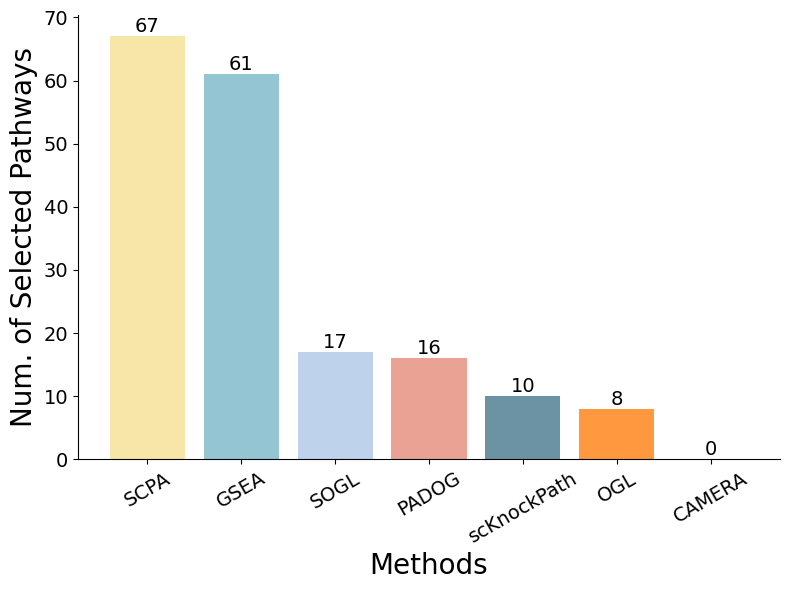

In [7]:
import matplotlib.pyplot as plt

# Extract counts for each method
counts = {method: len(df) for method, df in methods_results.items()}

# Sort methods by count (high -> low)
sorted_methods = sorted(counts, key=counts.get, reverse=True)
counts = {method: counts[method] for method in sorted_methods}

# Keep method-specific colors, then reorder colors with sorted methods
method_color_map = {
    'GSEA': '#78B7C9',
    'SCPA': '#F6E093',
    'CAMERA': '#97B319',
    'PADOG': '#E58B7B',
    'scKnockPath': '#46788E',
    'SOGL': '#AEC7E8',
    'OGL': '#FF7F0E',
}
colors = [method_color_map.get(method, '#999999') for method in counts.keys()]

# Create bar plot
plt.figure(figsize=(8,6))
bars = plt.bar(counts.keys(), counts.values(), color=colors, alpha=0.8)

tick_fontsize = 14
label_fontsize = 20
# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=tick_fontsize)

plt.ylabel('Num. of Selected Pathways', fontsize=label_fontsize)
plt.xlabel('Methods', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize,rotation=30)
plt.yticks(fontsize=tick_fontsize)
# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'./results/real_exp/beta_T2D_processed/{cell_type}_pathway_counts_bar_male.pdf')
plt.show()


In [3]:
gene2dict=model.transform_geneset_dict()
data_filename='data/T2D/beta_T2D_processed.h5ad'
cell_type='type B pancreatic cell'
class1='normal'
class2='type 2 diabetes mellitus'
obs_y='disease'

adata=sc.read_h5ad(data_filename)
adata = adata[adata.obs['cell_type'] == cell_type, :]
adata=adata[(adata.obs[obs_y]==class2)|(adata.obs[obs_y]==class1),:]
adata.var_names=adata.var['feature_name']
adata.var_names_make_unique()
# model.pathway_dict

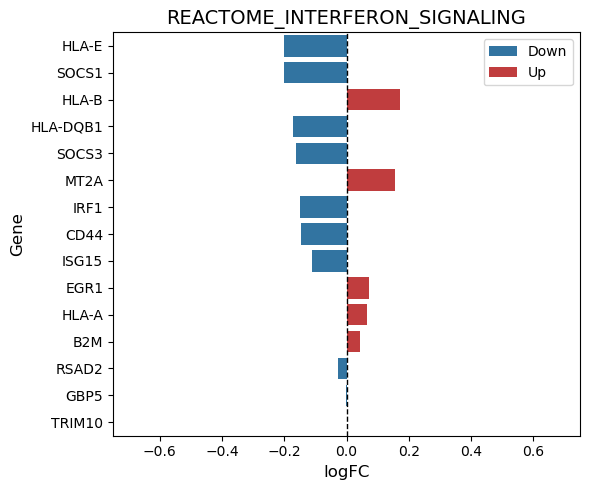

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def plot_pathway_genes_heatmap_by_logfc(
    adata,
    pathway_genes,
    obs_y='disease',
    class1='normal',
    class2='type 2 diabetes mellitus',
    display_names=('normal', 'type 2 diabetes mellitus'),
    n_genes=None,                  # None=用全部可用基因
    max_cells_per_group=200000,
    random_state=42,
    zscore=True,
    clip=(-4, 4),
    title='Pathway genes heatmap (sorted by logFC)',
    plot=False
):
    # 1) 在 adata 中找目标基因
    candidate_genes = [g for g in pathway_genes if g in adata.var_names]
    if len(candidate_genes) == 0:
        raise ValueError('目标通路基因在 adata.var_names 中都不存在。')

    # 2) 仅保留两组细胞
    ad = adata[adata.obs[obs_y].isin([class1, class2]), :].copy()
    if ad.n_obs == 0:
        raise ValueError(f'在 {obs_y} 中没有找到 {class1}/{class2} 细胞。')

    # 3) 计算 logFC，并按降序排序
    sub = ad[:, candidate_genes]
    X = sub.X.toarray()
    groups = ad.obs[obs_y].values
    mask1 = groups == class1
    mask2 = groups == class2
    if mask1.sum() == 0 or mask2.sum() == 0:
        raise ValueError('至少有一组没有细胞，无法计算 logFC。')

    mean1 = X[mask1].mean(axis=0)
    mean2 = X[mask2].mean(axis=0)
    logfc = np.log2(mean1 + 1) - np.log2(mean2 + 1)

    order_gene = np.argsort(np.abs(logfc))[::-1]  # 从大到小
    sorted_genes = [candidate_genes[i] for i in order_gene]
    sorted_logfc = logfc[order_gene]

    if n_genes is not None:
        n = min(n_genes, len(sorted_genes))
        sorted_genes = sorted_genes[:n]
        sorted_logfc = sorted_logfc[:n]

    # 4) 每组细胞下采样
    if plot:
        rng = np.random.default_rng(random_state)
        idx1 = np.where(mask1)[0]
        idx2 = np.where(mask2)[0]
        if len(idx1) > max_cells_per_group:
            idx1 = rng.choice(idx1, size=max_cells_per_group, replace=False)
        if len(idx2) > max_cells_per_group:
            idx2 = rng.choice(idx2, size=max_cells_per_group, replace=False)

        plot_idx = np.concatenate([idx1, idx2])
        ad_plot = ad[plot_idx, sorted_genes].copy()
        plot_groups = ad_plot.obs[obs_y].values

        # 5) 表达矩阵（可选 z-score）
        M = ad_plot.X.toarray() if sparse.issparse(ad_plot.X) else np.asarray(ad_plot.X)
        M = M.astype(float)

        # 明确保证画图列顺序为 logFC 从大到小
        col_order = [ad_plot.var_names.get_loc(g) for g in sorted_genes]
        M = M[:, col_order]

        if zscore:
            mu = M.mean(axis=0, keepdims=True)
            sd = M.std(axis=0, keepdims=True)
            sd[sd == 0] = 1.0
            M = (M - mu) / sd
            M = np.clip(M, clip[0], clip[1])

        # 6) 按组排序细胞（class1 在上）
        order_cell = np.argsort(plot_groups == class2)
        M = M[order_cell, :]
        sorted_groups = plot_groups[order_cell]

        # 7) 画图：左侧分组条 + 主热图（显示基因名）
        fig = plt.figure(figsize=(max(10, len(sorted_genes) * 0.28), 6))
        gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.05, 0.95], wspace=0.03)
        ax_bar = fig.add_subplot(gs[0, 0])
        ax_hm = fig.add_subplot(gs[0, 1])

        group_to_int = {class1: 0, class2: 1}
        bar_values = np.array([group_to_int[g] for g in sorted_groups]).reshape(-1, 1)
        bar_cmap = ListedColormap(['#67c5ad', '#f28b66'])
        ax_bar.imshow(bar_values, aspect='auto', cmap=bar_cmap, interpolation='nearest')
        ax_bar.set_xticks([])
        ax_bar.set_yticks([])
        for spine in ax_bar.spines.values():
            spine.set_visible(False)

        cmap = sns.diverging_palette(240, 35, s=85, l=75, as_cmap=True)
        sns.heatmap(
            M,
            ax=ax_hm,
            cmap=cmap,
            center=0 if zscore else None,
            cbar=True,
            xticklabels=sorted_genes,  # 按 logFC 降序显示
            yticklabels=False
        )
        ax_hm.tick_params(axis='x', labelrotation=90, labelsize=8)
        ax_hm.set_title(title, fontsize=14, pad=10)
        ax_hm.set_xlabel('Genes (sorted by logFC desc)')

        n1 = np.sum(sorted_groups == class1)
        n2 = np.sum(sorted_groups == class2)
        ax_bar.text(-0.8, (n1 - 1) / 2, display_names[0], va='center', ha='center', rotation=90, fontsize=10)
        ax_bar.text(-0.8, n1 + (n2 - 1) / 2, display_names[1], va='center', ha='center', rotation=90, fontsize=10)

        plt.tight_layout()
        plt.show()

    # 返回排序结果，便于后续检查
    logfc_df = pd.DataFrame({'Gene': sorted_genes, 'logFC': sorted_logfc})
    return logfc_df


pathway='REACTOME_INTERFERON_SIGNALING'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


In [8]:
abandoned_pathways=sogl_set-sckp_set
len(abandoned_pathways)

9

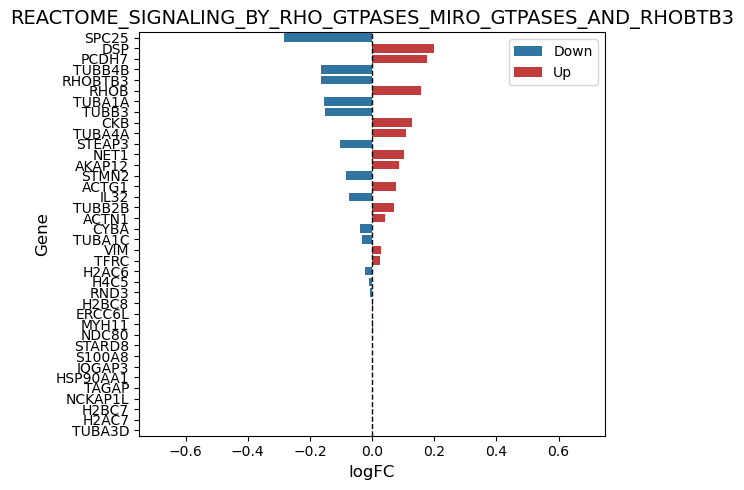

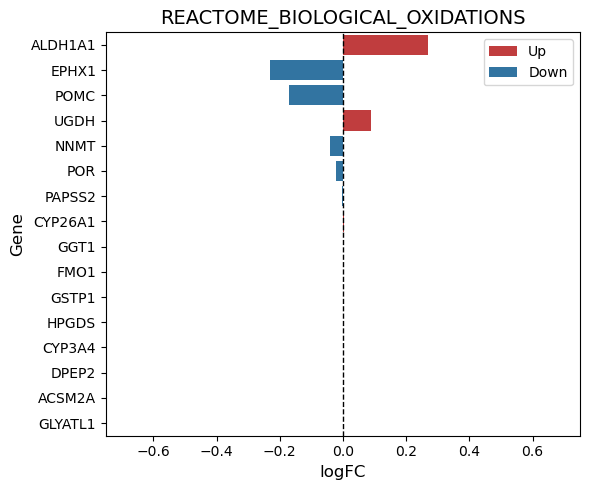

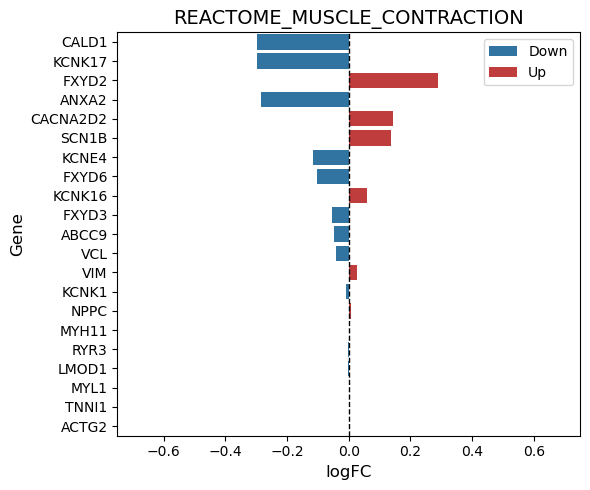

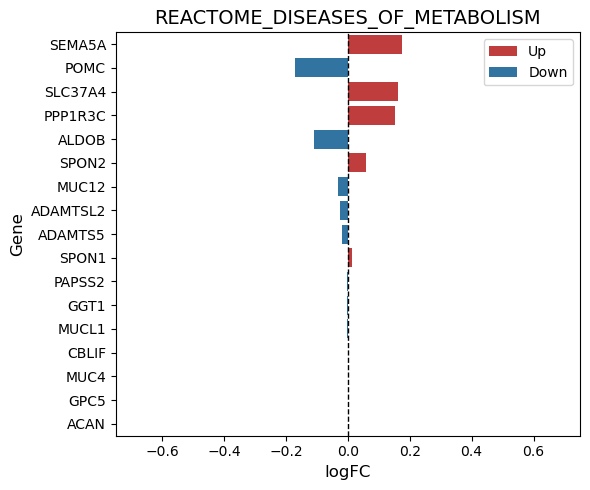

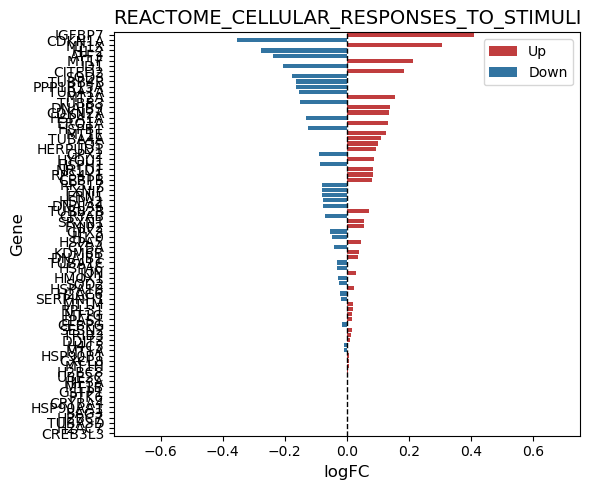

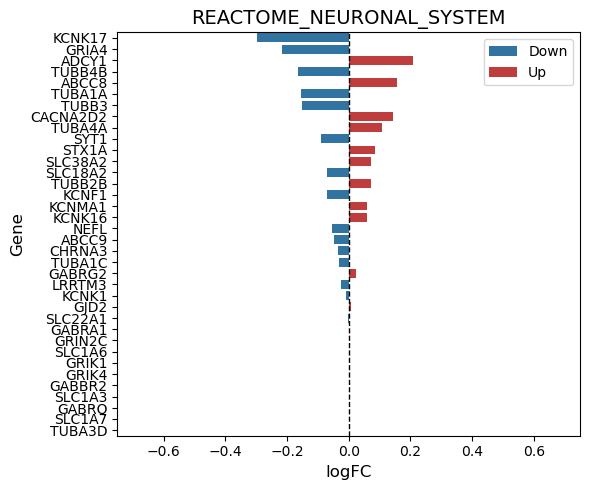

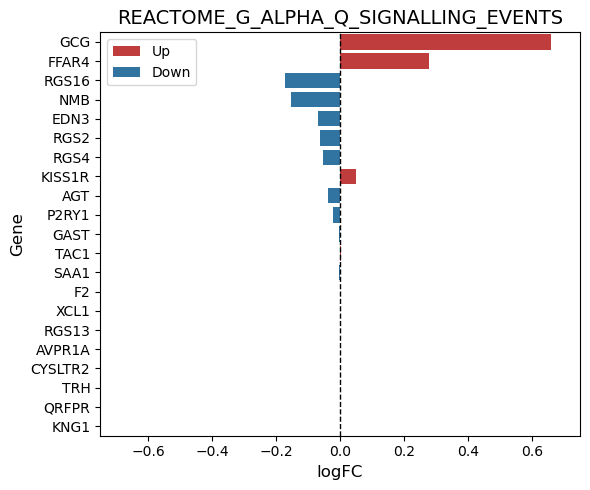

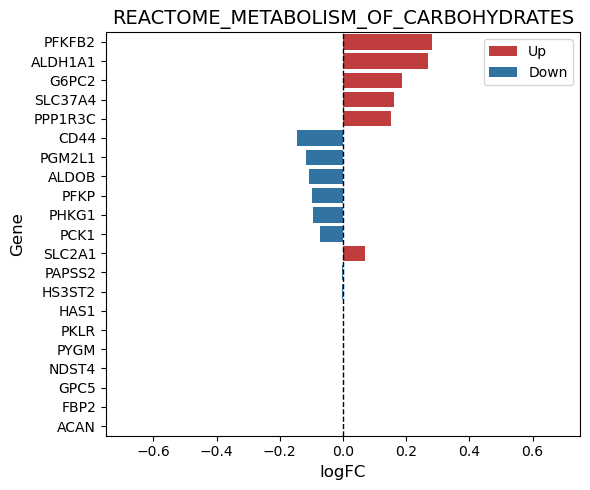

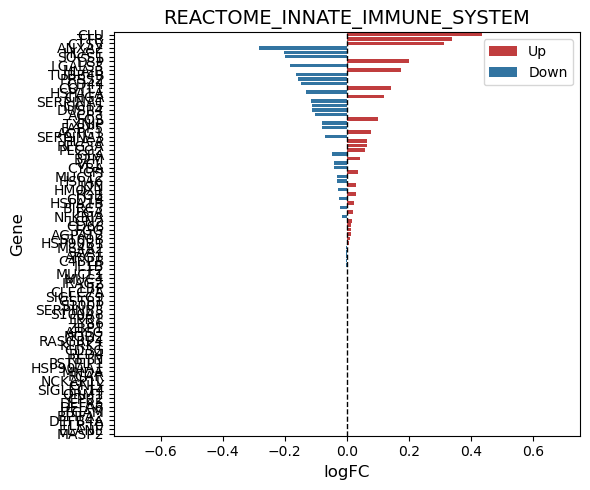

In [7]:
abandoned_pathways=sogl_set-sckp_set
for pathway in abandoned_pathways:
    pathway_genes=model.pathway_dict[pathway]
    logfc_df=plot_pathway_genes_heatmap_by_logfc(
        adata=adata,
        pathway_genes=pathway_genes,
        plot=False
    )

    # 按 logFC 排序，便于可视化
    plot_df = logfc_df
    plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=plot_df,
        x='logFC',
        y='Gene',
        hue='sign',
        dodge=False,
        palette={'Up': '#d62728', 'Down': '#1f77b4'}
    )

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel('logFC', fontsize=12)
    plt.ylabel('Gene', fontsize=12)
    plt.xlim(-0.75,0.75)
    plt.title(f'{pathway}', fontsize=14)
    plt.legend(title='')
    plt.tight_layout()
    plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
    plt.show()


In [45]:
print(methods_results['scKnockPath'].iloc[4])

Pathway    REACTOME_REGULATION_OF_INSULIN_LIKE_GROWTH_FAC...
Name: 32, dtype: object


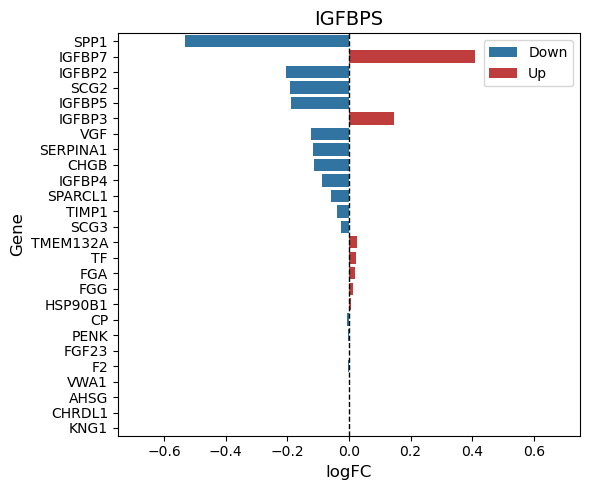

In [55]:
pathway='REACTOME_REGULATION_OF_INSULIN_LIKE_GROWTH_FACTOR_IGF_TRANSPORT_AND_UPTAKE_BY_INSULIN_LIKE_GROWTH_FACTOR_BINDING_PROTEINS_IGFBPS'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'IGFBPS', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


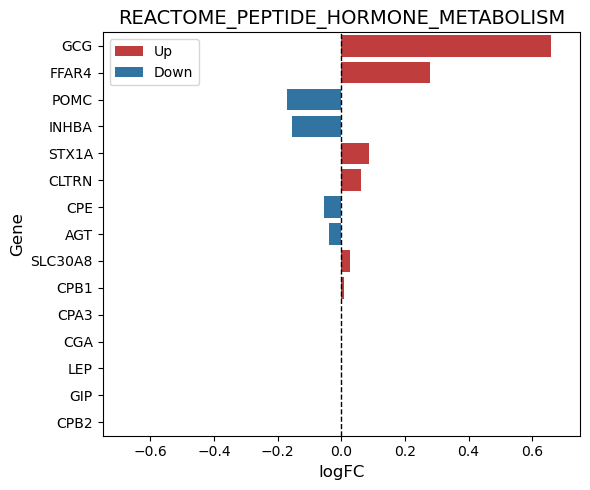

In [57]:


pathway='REACTOME_PEPTIDE_HORMONE_METABOLISM'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


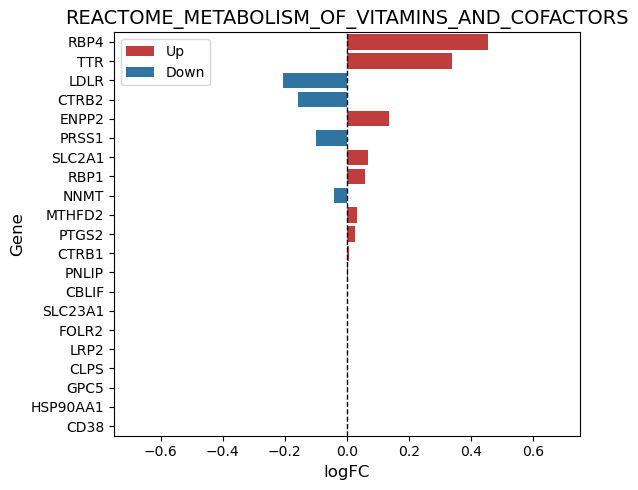

In [58]:



pathway='REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


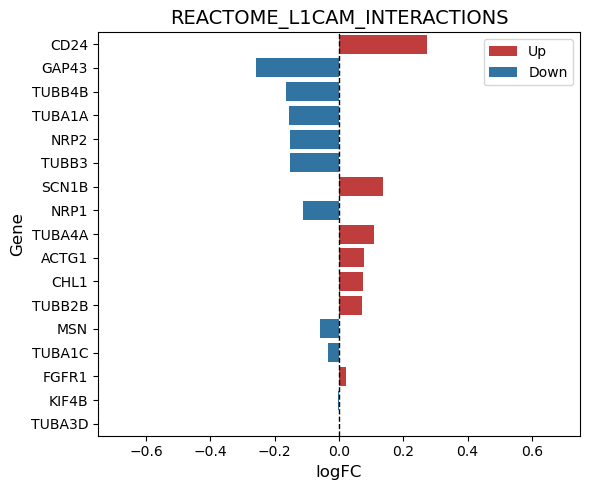

In [59]:





pathway='REACTOME_L1CAM_INTERACTIONS'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


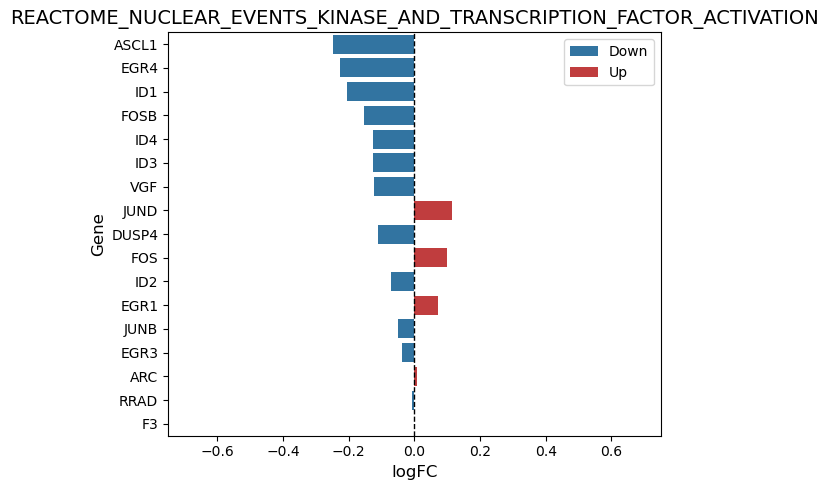

In [60]:
pathway='REACTOME_NUCLEAR_EVENTS_KINASE_AND_TRANSCRIPTION_FACTOR_ACTIVATION'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()


In [64]:
methods_results['scKnockPath'].Pathway

65                        REACTOME_INTERFERON_SIGNALING
26                  REACTOME_PEPTIDE_HORMONE_METABOLISM
30                          REACTOME_L1CAM_INTERACTIONS
69                         REACTOME_SARS_COV_INFECTIONS
32    REACTOME_REGULATION_OF_INSULIN_LIKE_GROWTH_FAC...
56             REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION
20        REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS
16                          REACTOME_SIGNALING_BY_NTRKS
21    REACTOME_NUCLEAR_EVENTS_KINASE_AND_TRANSCRIPTI...
64                REACTOME_NGF_STIMULATED_TRANSCRIPTION
Name: Pathway, dtype: object

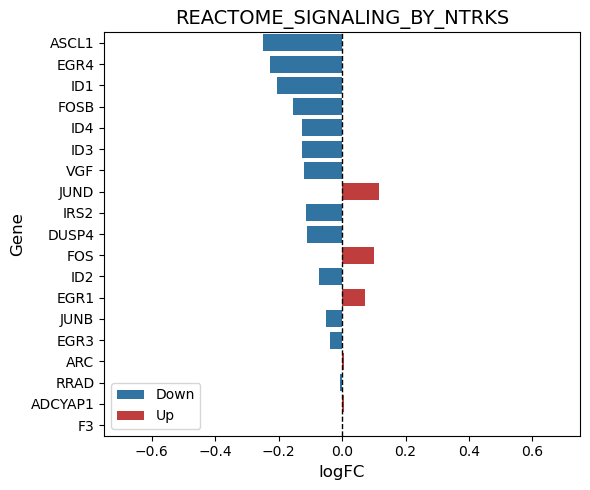

In [68]:
pathway='REACTOME_SIGNALING_BY_NTRKS'
pathway_genes=model.pathway_dict[pathway]
logfc_df=plot_pathway_genes_heatmap_by_logfc(
    adata=adata,
    pathway_genes=pathway_genes,
    plot=False
)

# 按 logFC 排序，便于可视化
plot_df = logfc_df
plot_df['sign'] = np.where(plot_df['logFC'] >= 0, 'Up', 'Down')

plt.figure(figsize=(6, 5))
sns.barplot(
    data=plot_df,
    x='logFC',
    y='Gene',
    hue='sign',
    dodge=False,
    palette={'Up': '#d62728', 'Down': '#1f77b4'}
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('logFC', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.xlim(-0.75,0.75)
plt.title(f'{pathway}', fontsize=14)
plt.legend(title='', loc='lower left')
plt.tight_layout()
plt.savefig(f'results/real_exp/beta_T2D_processed/{cell_type}_logfc_bar_{pathway}_genes.pdf')
plt.show()
